## Modèles CatBoost et deep learning

Ce notebook repart du fichier brut weatherAUS.csv.

L'idée n'est plus de réutiliser tel quel le nettoyage du notebook 1, mais d'adapter le pré-traitement au modèle :
- CatBoost profite d'un pré-traitement léger, notamment au niveau des des variables catégorielles et des valeurs manquantes ;
- le modèle de deep demande lui une préparation plus explicite, avec séparation train/validation/test et un pipeline de transformation dédié.

On suit surtout trois métriques : **ROC-AUC**, **PR-AUC** et **Brier score**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from weather_data import add_calendar_features, add_cyclical_date_features, load_raw_weather
from weather_modeling import score_probabilities, temporal_split, temporal_train_val_test_split

TARGET = "RainTomorrow"
RANDOM_STATE = 42
df_raw = load_raw_weather(encode_target=True, drop_risk_mm=True)
print(df_raw.shape)
df_raw.head()

(142193, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0


## 1. CatBoost

On entraîne ici un modèle global plutôt qu'un modèle par station dans un objectif d'avoir un modèle pour tout le pays plutot qu'autant de modèle que de stations/villes. Ce qu'on perd en précision, on le gagne en praticité.
Location devient donc une variable explicative à part entière.

Le pré-traitement est volontairement limité :
- variables calendaires simples ;
- conservation des variables catégorielles ;
- imputation des catégories manquantes par une valeur explicite.

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [3]:
from catboost import CatBoostClassifier

df_cb = add_calendar_features(df_raw)

train_cb, test_cb = temporal_split(df_cb, train_frac=0.8)

X_train_cb = train_cb.drop(columns=[TARGET, "Date"])
y_train_cb = train_cb[TARGET]

X_test_cb = test_cb.drop(columns=[TARGET, "Date"])
y_test_cb = test_cb[TARGET]

cat_cols_cb = X_train_cb.select_dtypes(include=["object"]).columns.tolist()

for frame in (X_train_cb, X_test_cb):
    for col in cat_cols_cb:
        frame[col] = frame[col].fillna("Missing").astype(str)

cb = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    verbose=200,
)

cb.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_cols_cb,
    eval_set=(X_test_cb, y_test_cb),
    use_best_model=True,
)

proba_cb = cb.predict_proba(X_test_cb)[:, 1]
score_probabilities(y_test_cb, proba_cb).to_frame("CatBoost")

0:	test: 0.8170416	best: 0.8170416 (0)	total: 282ms	remaining: 9m 23s
200:	test: 0.8765959	best: 0.8765959 (200)	total: 45.8s	remaining: 6m 49s
400:	test: 0.8845001	best: 0.8845001 (400)	total: 1m 31s	remaining: 6m 6s
600:	test: 0.8875238	best: 0.8875315 (599)	total: 2m 19s	remaining: 5m 24s
800:	test: 0.8887715	best: 0.8888090 (795)	total: 3m 5s	remaining: 4m 38s
1000:	test: 0.8894050	best: 0.8894136 (999)	total: 3m 52s	remaining: 3m 51s
1200:	test: 0.8895158	best: 0.8895763 (1189)	total: 4m 40s	remaining: 3m 6s
1400:	test: 0.8896122	best: 0.8897133 (1296)	total: 5m 26s	remaining: 2m 19s
1600:	test: 0.8895543	best: 0.8897613 (1470)	total: 6m 14s	remaining: 1m 33s
1800:	test: 0.8894227	best: 0.8897613 (1470)	total: 7m 2s	remaining: 46.6s
1999:	test: 0.8895208	best: 0.8897613 (1470)	total: 7m 49s	remaining: 0us

bestTest = 0.889761319
bestIteration = 1470

Shrink model to first 1471 iterations.


,CatBoost
ROC_AUC,0.889761
PR_AUC,0.743198
Brier,0.128921


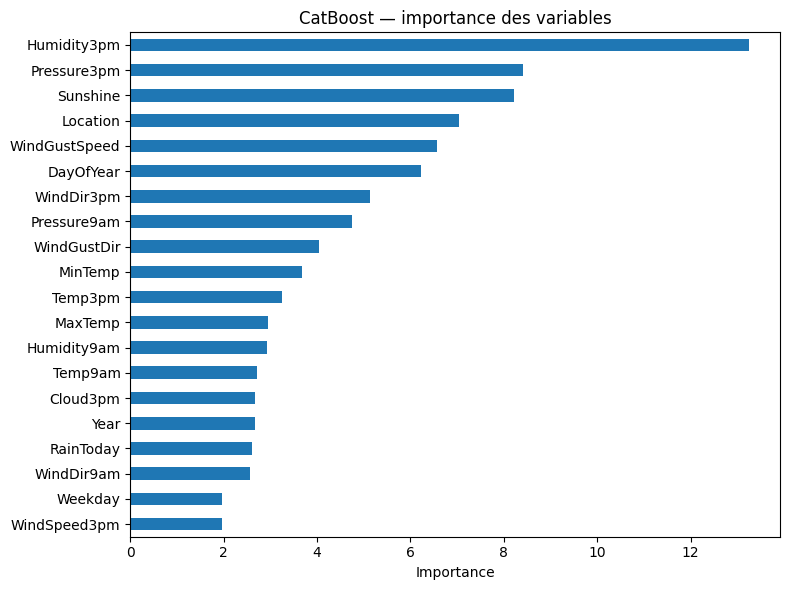

In [4]:
importance = pd.Series(cb.get_feature_importance(), index=X_train_cb.columns)
importance = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
importance.sort_values().plot(kind="barh")
plt.title("CatBoost — importance des variables")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 2. Modèle de deep (MLP)

Ici, on repart aussi du fichier brut, mais avec un pipeline distinct :
- encodage cyclique de la date ;
- indicateurs de valeurs manquantes sur les variables numériques ;
- standardisation et one-hot encoding ;
- split temporel en train / validation / test pour l'early stopping.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df_dl = add_cyclical_date_features(df_raw)

if "RainToday" in df_dl.columns:
    df_dl["RainToday"] = df_dl["RainToday"].map({"No": 0, "Yes": 1})

train_dl, val_dl, test_dl = temporal_train_val_test_split(df_dl, train_frac=0.7, val_frac=0.1)

X_train_dl = train_dl.drop(columns=[TARGET, "Date"])
y_train_dl = train_dl[TARGET].astype(np.float32)

X_val_dl = val_dl.drop(columns=[TARGET, "Date"])
y_val_dl = val_dl[TARGET].astype(np.float32)

X_test_dl = test_dl.drop(columns=[TARGET, "Date"])
y_test_dl = test_dl[TARGET].astype(np.float32)

num_cols_dl = X_train_dl.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_dl = X_train_dl.select_dtypes(include=["object"]).columns.tolist()

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocessor_dl = ColumnTransformer([
    ("num", numeric_pipe, num_cols_dl),
    ("cat", categorical_pipe, cat_cols_dl),
])

X_train_dl_arr = preprocessor_dl.fit_transform(X_train_dl).astype(np.float32)
X_val_dl_arr = preprocessor_dl.transform(X_val_dl).astype(np.float32)
X_test_dl_arr = preprocessor_dl.transform(X_test_dl).astype(np.float32)

X_train_dl_arr.shape

(99535, 138)

In [6]:
import tensorflow as tf
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_STATE)

model = tf.keras.Sequential([
    layers.Input(shape=(X_train_dl_arr.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

p = float(y_train_dl.mean())
class_weight = {0: 1.0, 1: (1 - p) / p}

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
    )
]

history = model.fit(
    X_train_dl_arr,
    y_train_dl,
    validation_data=(X_val_dl_arr, y_val_dl),
    epochs=30,
    batch_size=1024,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - loss: 0.7789 - pr_auc: 0.6193 - roc_auc: 0.8329 - val_loss: 0.4233 - val_pr_auc: 0.6858 - val_roc_auc: 0.8681
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6944 - pr_auc: 0.6944 - roc_auc: 0.8716 - val_loss: 0.4080 - val_pr_auc: 0.7074 - val_roc_auc: 0.8780
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6727 - pr_auc: 0.7149 - roc_auc: 0.8800 - val_loss: 0.3973 - val_pr_auc: 0.7158 - val_roc_auc: 0.8820
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6617 - pr_auc: 0.7216 - roc_auc: 0.8841 - val_loss: 0.3932 - val_pr_auc: 0.7209 - val_roc_auc: 0.8843
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6499 - pr_auc: 0.7334 - roc_auc: 0.8885 - val_loss: 0.3941 - val_pr_auc: 0.7262 - val_roc_auc: 0.8869
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6444 - pr_auc: 0.7369 - roc_auc: 0.8905 - val_loss: 0.3842 - val_pr_auc: 0.7297 - val_roc_auc: 0.8888
Epoch 7/30
98/98 ━━━━━━━━━

In [7]:
proba_val_dl = model.predict(X_val_dl_arr, verbose=0).ravel()
proba_test_dl = model.predict(X_test_dl_arr, verbose=0).ravel()

scores_dl = pd.concat([score_probabilities(y_val_dl, proba_val_dl).rename("Validation"), score_probabilities(y_test_dl, proba_test_dl).rename("Test")], axis=1)
scores_dl

,Validation,Test
ROC_AUC,0.897143,0.886843
PR_AUC,0.749245,0.738446
Brier,0.115102,0.126844


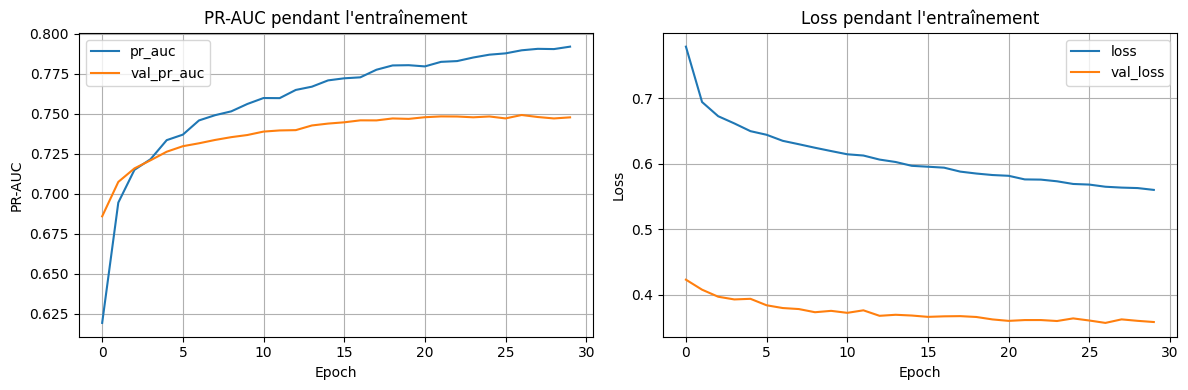

In [9]:
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[["pr_auc", "val_pr_auc"]].plot(ax=axes[0])
axes[0].set_title("PR-AUC pendant l'entraînement")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("PR-AUC")
axes[0].grid(True)

history_df[["loss", "val_loss"]].plot(ax=axes[1])
axes[1].set_title("Loss pendant l'entraînement")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Conclusion

Les deux modèles performent bien mieux que ceux du notebook précédent. Dans les deux cas, le split temporel est important pour éviter d'évaluer le modèle sur des données trop proches de ce qu'il a déjà vu.